# Main V6 — Frequency-Band PDC Pipeline

## Motivation

V3–V5b use **broadband GC** (A_total = Σ|A_k| over all lags), which collapses all frequency-domain information into a single directed graph. The seminal work of Hejazi & Motie Nasrabadi (2019, *Epilepsy & Behavior*) found that **alpha-band (8–13 Hz) directed connectivity** is the most discriminative for preictal detection, substantially outperforming broadband measures. DTF and PDC in specific bands are also used by Schelter et al. (2006, *Clinical Neurophysiology*).

V6 tests this directly:

1. **Refit VAR(20)** on each window, keeping the full coefficient matrix **B** (18 × 360) instead of discarding it. VAR(5) captures only ~20ms — shorter than one alpha cycle (100ms). VAR(20) = 78ms gives enough lags for meaningful spectral decomposition. Hejazi & Motie Nasrabadi (2019) used p=10; p=20 is more conservative and used here.
2. **Compute PDC** (Partial Directed Coherence, Baccalá & Sameshima 2001) at every frequency, then **band-average** over delta / theta / alpha / beta.
3. **Extract 67 graph descriptors** (same as V4) from each band's 18×18 PDC matrix → 268 features total.
4. **Run the same LOPO ML pipeline** as V4 (LR/RF/XGB/SVM with inner GroupKFold).
5. Test each band separately *and* all-band combined to isolate which band drives performance.

## Why PDC_ORDER ≠ GC_ORDER

| Use | Order | Rationale |
|-----|-------|-----------|
| Broadband GC (V3–V5b) | p=5 | AIC/BIC optimal for A_total = Σ\|A_k\| (time-domain) |
| Frequency-band PDC (V6) | p=20 | Needs ≥1 oscillatory cycle per band; p=5 at 256Hz = 20ms — blind to alpha (100ms period) |

## PDC formula (Baccalá & Sameshima 2001)

For VAR(p) model X(t) = Σ A_k X(t−k) + ε, define the spectral matrix:

    H(f) = I − Σ_{k=1}^{p} A_k · exp(−j·2π·f·k / fs)

PDC from channel j → i at frequency f:

    PDC_{ij}(f) = H_{ij}(f) / sqrt( Σ_k |H_{kj}(f)|² )

Band PDC matrix: average |PDC(f)|² over frequency bins within the band.

## Frequency bands
| Band  | Hz    |
|-------|-------|
| Delta | 0.5–4 |
| Theta | 4–8   |
| Alpha | 8–13  |
| Beta  | 13–30 |

## 0 · Imports & config

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, GC_ORDER,
    EXCLUDED_PATIENTS, GC_MATRICES_DIR_V3, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)
from summary_parser import parse_summary, parse_all_summaries
from data_loader import load_edf
from preprocessing import preprocess_file

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import GroupKFold, GridSearchCV
from sklearn.metrics          import (roc_auc_score, average_precision_score,
                                       roc_curve, precision_recall_curve)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_XGB = False

np.random.seed(RANDOM_SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── V6-specific constants ──────────────────────────────────────────────────
# PDC_ORDER is separate from GC_ORDER (=5).
# VAR(5) at 256 Hz = 19.5ms — too short to resolve alpha (100ms cycle).
# VAR(20) = 78ms captures enough oscillatory structure for delta–beta PDC.
# Hejazi & Motie Nasrabadi (2019) used p=10; we use p=20 for more fidelity.
PDC_ORDER = 20

PDC_CACHE_DIR = os.path.join(CODE_DIR, 'cache_pdc_var20')
os.makedirs(PDC_CACHE_DIR, exist_ok=True)

# Frequency bands (name, low_hz, high_hz)
BANDS = [
    ('delta', 0.5,  4.0),
    ('theta', 4.0,  8.0),
    ('alpha', 8.0, 13.0),
    ('beta', 13.0, 30.0),
]
BAND_NAMES = [b[0] for b in BANDS]

print(f'Data root    : {DATA_ROOT}')
print(f'PDC cache    : {PDC_CACHE_DIR}')
print(f'FS={FS} Hz   GC_ORDER={GC_ORDER} (broadband)   PDC_ORDER={PDC_ORDER} (freq-domain)')
print(f'Bands        : {BAND_NAMES}')
print(f'B matrix dim : {N_CHANNELS} × {PDC_ORDER * N_CHANNELS}  (18 channels × {PDC_ORDER} lags)')
print(f'XGBoost      : {"available" if HAS_XGB else "unavailable"}')
print('V6 PDC notebook ready.')

Data root    : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/data/physionet
PDC cache    : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/cache_pdc_var20
FS=256 Hz   GC_ORDER=5 (broadband)   PDC_ORDER=20 (freq-domain)
Bands        : ['delta', 'theta', 'alpha', 'beta']
B matrix dim : 18 × 360  (18 channels × 20 lags)
XGBoost      : available
V6 PDC notebook ready.


## 1 · PDC core functions

In [2]:
# Cell 1 — PDC computation

def estimate_var_matrix(
    window: np.ndarray,
    p: int = PDC_ORDER,
    eps: float = 1e-10,
):
    """
    Fit VAR(p) via OLS and return the full coefficient matrix B.

    Model: X(t) = A_1 X(t-1) + ... + A_p X(t-p) + noise

    Returns
    -------
    B     : np.ndarray  shape (n_ch, p * n_ch)
            B[:, k*n_ch:(k+1)*n_ch] = A_{k+1}  (lag k+1, k=0..p-1)
    valid : bool
    """
    n_ch, T = window.shape
    X = window - window.mean(axis=1, keepdims=True)
    T_eff = T - p
    # Need more observations than parameters for OLS to be identified
    if T_eff < n_ch * p + 1:
        return np.zeros((n_ch, p * n_ch), dtype=np.float64), False

    Y = X[:, p:]                                                      # (n_ch, T_eff)
    Z = np.vstack([X[:, p - lag : p - lag + T_eff]
                   for lag in range(1, p + 1)])                       # (p*n_ch, T_eff)

    # eps*I regularisation ensures ZZT is always positive definite → always invertible.
    # No rank check needed: with T_eff=5100 >> p*n_ch=360 and real EEG,
    # ZZT is well-conditioned before regularisation.
    ZZT = (Z @ Z.T) / T_eff + eps * np.eye(p * n_ch)

    YZT = (Y @ Z.T) / T_eff
    B   = YZT @ np.linalg.inv(ZZT)                                    # (n_ch, p*n_ch)
    return B.astype(np.float64), True


def compute_pdc_bands(
    B: np.ndarray,
    bands: list = BANDS,
    fs: int = FS,
    p: int = PDC_ORDER,
    n_freq_per_hz: float = 4.0,
) -> dict:
    """
    Compute band-averaged PDC matrices from a VAR(p) coefficient matrix B.

    PDC formula (Baccalá & Sameshima 2001):
      H(f) = I - sum_{k=1}^{p} A_k * exp(-j*2*pi*f*k/fs)
      PDC_{ij}(f) = |H_{ij}(f)| / sqrt(sum_rows |H_{rj}(f)|^2)
      BandPDC_{ij} = mean_f( PDC_{ij}(f)^2 )  over frequencies in band

    Column sums: by construction sum_i BandPDC[i,j] = 1 for each j.

    Parameters
    ----------
    B              : (n_ch, p*n_ch)  VAR coefficient matrix
    bands          : list of (name, low_hz, high_hz)
    fs             : sampling frequency
    p              : VAR order (must match B's second dimension / n_ch)
    n_freq_per_hz  : frequency resolution (bins per Hz); 4 gives delta=14, alpha=20, beta=68 bins

    Returns
    -------
    band_pdc : dict  {band_name: np.ndarray (n_ch, n_ch)}
               BandPDC[i, j] = mean squared PDC from j -> i
    """
    n_ch = B.shape[0]
    I = np.eye(n_ch, dtype=complex)

    # Extract lag matrices: A_k = B[:, (k-1)*n_ch : k*n_ch]
    A_lags = [B[:, k * n_ch : (k + 1) * n_ch] for k in range(p)]    # list of p (n_ch, n_ch)

    band_pdc = {}
    for band_name, f_low, f_high in bands:
        n_bins = max(4, int((f_high - f_low) * n_freq_per_hz))
        freqs  = np.linspace(f_low, f_high, n_bins, endpoint=False)

        # Accumulate |PDC|^2 over frequencies
        pdc_sum = np.zeros((n_ch, n_ch), dtype=np.float64)

        for f in freqs:
            # H(f) = I - sum_{k=1}^{p} A_k * exp(-j*2*pi*f*k/fs)
            H = I.copy()
            for k, Ak in enumerate(A_lags):
                H -= Ak * np.exp(-1j * 2 * np.pi * f * (k + 1) / fs)

            # PDC_{ij}(f) = |H_{ij}(f)| / sqrt(sum_rows |H_{rj}(f)|^2)
            col_norms = np.sqrt((np.abs(H) ** 2).sum(axis=0))         # (n_ch,)
            col_norms = np.where(col_norms < 1e-15, 1e-15, col_norms)
            PDC = np.abs(H) / col_norms[np.newaxis, :]                # (n_ch, n_ch)

            pdc_sum += PDC ** 2

        band_pdc[band_name] = (pdc_sum / n_bins).astype(np.float32)

    return band_pdc


print('PDC functions defined.')

# Sanity check: B should be (18, 360) with p=20
_dummy = np.random.randn(N_CHANNELS, 20 * FS).astype(np.float32)
_B, _ok = estimate_var_matrix(_dummy, p=PDC_ORDER)
_bpdc   = compute_pdc_bands(_B, p=PDC_ORDER)
print(f'Sanity check: B shape={_B.shape}  valid={_ok}  (expect (18, {PDC_ORDER*18}))')
for bname, mat in _bpdc.items():
    col_sums = mat.sum(axis=0)   # each column should sum to ~1
    print(f'  {bname}: mean={mat.mean():.4f}  col_sum_min={col_sums.min():.3f}  col_sum_max={col_sums.max():.3f}')

PDC functions defined.
Sanity check: B shape=(18, 360)  valid=True  (expect (18, 360))
  delta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  theta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  alpha: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  beta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000


## 2 · Feature extraction from PDC matrices

Same 67-feature descriptor as V4 (in-degree / out-degree / net-flow / scalars / SVD), applied to each of the 4 band PDC matrices independently. Total: 4 × 67 = 268 features.

In [3]:
# Cell 2 — Feature extraction (identical logic to V4, applied per band)

def extract_graph_features(A: np.ndarray) -> np.ndarray:
    """
    Extract 67 patient-invariant graph descriptors from a single 18x18
    directed connectivity matrix (PDC or GC).

    Applies Frobenius normalization first so absolute magnitudes don't
    encode patient-specific amplitude differences.
    """
    # Frobenius normalization — makes scale-invariant
    frob = np.linalg.norm(A, 'fro')
    if frob > 1e-10:
        A = A / frob

    n    = A.shape[0]
    off  = ~np.eye(n, dtype=bool)
    a_off = A[off]

    # Group A: channel-level (54)
    in_deg   = A.sum(axis=1) - np.diag(A)       # row sum excl diagonal
    out_deg  = A.sum(axis=0) - np.diag(A)       # col sum excl diagonal
    net_flow = out_deg - in_deg

    # Group B: network scalars (8)
    mean_off = a_off.mean()
    std_off  = a_off.std()
    max_off  = a_off.max()
    min_off  = a_off.min()

    asym     = np.abs(A - A.T)
    asym_off = asym[np.triu_indices(n, k=1)]
    mean_asym = asym_off.mean()
    std_asym  = asym_off.std()

    thr      = 0.5 * max(float(max_off), 1e-12)
    density  = float((a_off > thr).mean())
    eigvals  = np.linalg.eigvals(A)
    spec_rad = float(np.max(np.abs(eigvals)))

    # Group C: top-5 singular values (5)
    sv = np.linalg.svd(A, compute_uv=False)
    sv5 = sv[:5] if len(sv) >= 5 else np.pad(sv, (0, 5 - len(sv)))

    return np.concatenate([
        in_deg, out_deg, net_flow,
        [mean_off, std_off, max_off, min_off,
         mean_asym, std_asym, density, spec_rad],
        sv5,
    ]).astype(np.float32)


def feature_names_for_band(band: str) -> list:
    names = []
    for prefix in ['in_deg', 'out_deg', 'net_flow']:
        names += [f'{band}_{prefix}_{c}' for c in CANONICAL_CHANNELS]
    names += [f'{band}_{s}' for s in
              ['mean_off', 'std_off', 'max_off', 'min_off',
               'mean_asym', 'std_asym', 'density', 'spec_radius']]
    names += [f'{band}_sv_{k}' for k in range(1, 6)]
    return names


ALL_FEATURE_NAMES = []
for bname in BAND_NAMES:
    ALL_FEATURE_NAMES += feature_names_for_band(bname)

FEATS_PER_BAND = 67
print(f'Features per band : {FEATS_PER_BAND}')
print(f'Total (all bands) : {len(ALL_FEATURE_NAMES)}')
print(f'Band feature slices:')
for i, b in enumerate(BAND_NAMES):
    lo, hi = i * FEATS_PER_BAND, (i + 1) * FEATS_PER_BAND
    print(f'  {b}: [{lo}:{hi}]')

Features per band : 67
Total (all bands) : 268
Band feature slices:
  delta: [0:67]
  theta: [67:134]
  alpha: [134:201]
  beta: [201:268]


## 3 · Load data and compute / cache PDC features

The V3 cache stores A_total (18×18) but **not** the full B coefficient matrix, so we re-read EDF files from disk. Features are cached per-patient to `cache_pdc_var20/<pid>/`.

**Runtime estimate**: VAR(20) is ~4× slower than VAR(5) per window. Expect **20–40 min total** on first run (cache-once architecture — subsequent runs load in <30s).

In [4]:
# Cell 3 — Parse summaries
all_seizures = parse_all_summaries(DATA_ROOT)

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

print(f'Patients to process: {len(patients_all)}')
print(f'  {patients_all}')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [5]:
# Cell 4 — Compute/load PDC features per patient
#
# Cache layout:
#   cache_pdc_var20/<pid>/features.npy   shape (N_windows, 268)
#   cache_pdc_var20/<pid>/labels.npy     shape (N_windows,)
#
# NOTE: pdc_features_v6/ (without _p20) was computed with the wrong VAR order
# (p=5) and must NOT be used. This cell uses cache_pdc_var20/ (p=20).

def _patient_cache_paths(pid):
    pdir = Path(PDC_CACHE_DIR) / pid
    return pdir / 'features.npy', pdir / 'labels.npy'


def load_pdc_features_patient(pid, seizure_map, force_recompute=False):
    """
    Load (or compute and cache) PDC features for one patient.

    Returns
    -------
    X : (N, 268)  float32
    y : (N,)      int8   {0=interictal, 1=preictal}
    """
    feat_path, lab_path = _patient_cache_paths(pid)

    if not force_recompute and feat_path.exists() and lab_path.exists():
        X = np.load(str(feat_path))
        y = np.load(str(lab_path))
        print(f'  [PDC] Cache hit: {pid}  shape={X.shape}')
        return X, y

    feat_path.parent.mkdir(parents=True, exist_ok=True)
    pdir = Path(DATA_ROOT) / pid

    all_feats = []   # list of (N_win, 268) arrays
    all_labels = []  # list of (N_win,) arrays

    for edf_fname, seizures in sorted(seizure_map.items()):
        edf_path = pdir / edf_fname
        if not edf_path.exists():
            continue
        try:
            raw_data, fs = load_edf(str(edf_path))
        except Exception as e:
            print(f'  [PDC] Load error {edf_fname}: {e}')
            continue

        windows, labels, _ = preprocess_file(raw_data, seizures, fs)
        if len(windows) == 0:
            continue

        # Compute VAR(PDC_ORDER) + PDC per window
        file_feats = []
        n_invalid  = 0
        for win in windows:
            B, ok = estimate_var_matrix(win, p=PDC_ORDER)
            if not ok:
                n_invalid += 1
                file_feats.append(np.zeros(len(BAND_NAMES) * FEATS_PER_BAND, dtype=np.float32))
                continue

            band_pdcs = compute_pdc_bands(B, p=PDC_ORDER)
            all_band_feats = np.concatenate([
                extract_graph_features(band_pdcs[bname])
                for bname in BAND_NAMES
            ])  # 268-dim
            file_feats.append(all_band_feats)

        file_feats = np.stack(file_feats, axis=0)  # (N_win, 268)

        # Drop invalid windows (all-zero feature rows where VAR failed)
        valid_mask = ~np.all(file_feats == 0, axis=1)
        file_feats = file_feats[valid_mask]
        labels     = labels[valid_mask]

        if n_invalid > 0:
            print(f'    {edf_fname}: {n_invalid} rank-deficient windows dropped')

        all_feats.append(file_feats)
        all_labels.append(labels)

    if not all_feats:
        return None, None

    X = np.concatenate(all_feats,  axis=0).astype(np.float32)
    y = np.concatenate(all_labels, axis=0).astype(np.int8)

    np.save(str(feat_path), X)
    np.save(str(lab_path),  y)
    print(f'  [PDC] Computed+cached (p={PDC_ORDER}): {pid}  shape={X.shape}')
    return X, y


# ── Run for all patients ───────────────────────────────────────────────────
pdc_raw = {}   # pid -> (X_all, y_all)   — before interictal cap

t0 = time.time()
for pid in patients_all:
    if pid not in all_seizures:
        continue
    X, y = load_pdc_features_patient(pid, all_seizures[pid])
    if X is None or (y == 1).sum() == 0:
        print(f'  [PDC] Skipping {pid}: no preictal windows')
        continue
    pdc_raw[pid] = (X, y)

elapsed = time.time() - t0
print(f'\nDone in {elapsed/60:.1f} min')
print(f'Patients with PDC features: {sorted(pdc_raw.keys())}')

    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — skipping preictal label.
  [PDC] Computed+cached (p=20): chb01  shape=(1333, 268)
    [LABEL] Seizure at 130s: preictal window out of bounds (would start at -1670s) — skipping preictal label.
  [PDC] Computed+cached (p=20): chb02  shape=(635, 268)
    [LABEL] Seizure at 362s: preictal window out of bounds (would start at -1438s) — skipping preictal label.
    [LABEL] Seizure at 731s: preictal window out of bounds (would start at -1069s) — skipping preictal label.
    [LABE

In [6]:
# Cell 5 — Apply interictal cap (same as V3/V4)

pdc_data = {}   # pid -> (X_capped, y)

for pid, (X, y) in pdc_raw.items():
    n_pre = int((y == 1).sum())
    n_int = int((y == 0).sum())
    cap   = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)

    if n_int > cap:
        rng     = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx  = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx  = np.where(y == 1)[0]
        keep     = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]

    pdc_data[pid] = (X, y)
    print(f'  {pid}: pre={int((y==1).sum())}  int={int((y==0).sum())}  '
          f'ratio=1:{int((y==0).sum())//max(int((y==1).sum()),1)}')

patient_ids = sorted(pdc_data.keys())
print(f'\n{len(patient_ids)} patients, feature shape: {pdc_data[patient_ids[0]][0].shape}')
print(f'Total preictal   : {sum(int((y==1).sum()) for _,(_, y) in pdc_data.items()):,}')
print(f'Total interictal : {sum(int((y==0).sum()) for _,(_, y) in pdc_data.items()):,}')

  chb01: pre=296  int=1037  ratio=1:3
  chb02: pre=296  int=339  ratio=1:1
  chb03: pre=444  int=899  ratio=1:2
  chb04: pre=296  int=1480  ratio=1:5
  chb05: pre=444  int=582  ratio=1:1
  chb06: pre=1037  int=5000  ratio=1:4
  chb07: pre=445  int=2225  ratio=1:5
  chb08: pre=741  int=535  ratio=1:0
  chb09: pre=592  int=2231  ratio=1:3
  chb10: pre=888  int=3062  ratio=1:3
  chb13: pre=444  int=947  ratio=1:2
  chb14: pre=774  int=687  ratio=1:0
  chb15: pre=320  int=1600  ratio=1:5
  chb16: pre=347  int=493  ratio=1:1
  chb17: pre=444  int=384  ratio=1:0
  chb18: pre=592  int=699  ratio=1:1
  chb19: pre=296  int=475  ratio=1:1
  chb20: pre=369  int=536  ratio=1:1
  chb22: pre=296  int=513  ratio=1:1
  chb23: pre=608  int=1382  ratio=1:2
  chb24: pre=939  int=1684  ratio=1:1

21 patients, feature shape: (1333, 268)
Total preictal   : 10,908
Total interictal : 26,790


## 4 · LOPO ML pipeline

Same as V4 — LR, RF, XGB, SVM with inner GroupKFold and AUC-PR scoring. Tests three feature sets:

1. **All-band combined** (268 features)
2. **Alpha only** (67 features) — Hejazi & Motie Nasrabadi (2019) hypothesis
3. **Per-band loop** (delta / theta / alpha / beta separately)

In [7]:
# Cell 6 — LOPO machinery (identical logic to V4)

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_test, n_interictal_hours):
    if len(np.unique(y_test)) < 2:
        return None
    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)
    fpr, tpr, thr = roc_curve(y_test, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thr[j_idx])
    pred   = (probs >= thresh).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    sens   = tp / max(tp + fn, 1)
    spec   = tn / max(tn + fp, 1)
    prec   = tp / max(tp + fp, 1)
    f1     = 2 * prec * sens / max(prec + sens, 1e-9)
    bal    = 0.5 * (sens + spec)
    fpr_h  = false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_test, STEP_SEC)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=bal,
                fpr_per_hour=fpr_h)


def make_lr():
    return ('LR', Pipeline([('scl', StandardScaler()),
                             ('clf', LogisticRegression(
                                 max_iter=400, solver='lbfgs',
                                 class_weight='balanced',
                                 random_state=RANDOM_SEED))]),
            {'clf__C': [0.01, 0.1, 1.0, 10.0]})


def make_rf():
    return ('RF', Pipeline([('scl', StandardScaler()),
                             ('clf', RandomForestClassifier(
                                 n_estimators=300,
                                 class_weight='balanced_subsample',
                                 n_jobs=-1, random_state=RANDOM_SEED))]),
            {'clf__max_depth':        [8, 16],
             'clf__min_samples_leaf': [5, 10],
             'clf__max_features':     ['sqrt', 'log2']})


def make_xgb():
    if not HAS_XGB:
        from sklearn.ensemble import GradientBoostingClassifier
        return ('GBM', Pipeline([('scl', StandardScaler()),
                                  ('clf', GradientBoostingClassifier(random_state=RANDOM_SEED))]),
                {'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]})
    return ('XGB', Pipeline([('scl', StandardScaler()),
                              ('clf', XGBClassifier(
                                  n_estimators=300, eval_metric='aucpr',
                                  use_label_encoder=False, tree_method='hist',
                                  n_jobs=-1, random_state=RANDOM_SEED))]),
            {'clf__max_depth':      [3, 5],
             'clf__learning_rate':  [0.05, 0.1],
             'clf__subsample':      [0.7, 1.0],
             'clf__colsample_bytree': [0.7, 1.0],
             'clf__reg_lambda':     [1.0, 5.0]})


def make_svm():
    return ('SVM', Pipeline([('scl', StandardScaler()),
                              ('clf', SVC(kernel='rbf', class_weight='balanced',
                                         probability=True, random_state=RANDOM_SEED))]),
            {'clf__C': [0.1, 1.0, 10.0]})


def run_lopo_for_model(factory, feat_data, pids, tag='',
                        max_train_per_model=None):
    """
    LOPO loop for one ML model.

    Parameters
    ----------
    factory          : callable -> (name, Pipeline, param_grid)
    feat_data        : dict pid -> (X, y)
    pids             : ordered list of patient IDs to loop over
    tag              : suffix added to model name in output (e.g. 'alpha')
    max_train_per_model : int or None  — SVM subsample
    """
    name, pipe_template, param_grid = factory()
    full_name = f'{name}_{tag}' if tag else name
    print(f'\n══ {full_name} — LOPO ({len(pids)} folds) ' + '═' * (35 - len(full_name)))
    rows = []
    t_start = time.time()

    for fold_idx, test_pid in enumerate(pids, 1):
        X_tr = np.concatenate([feat_data[p][0] for p in pids if p != test_pid])
        y_tr = np.concatenate([feat_data[p][1] for p in pids if p != test_pid])
        groups = np.concatenate(
            [np.full(len(feat_data[p][1]), i)
             for i, p in enumerate(pids) if p != test_pid])
        X_te, y_te = feat_data[test_pid]

        if max_train_per_model and len(X_tr) > max_train_per_model:
            rng = np.random.default_rng(RANDOM_SEED + fold_idx)
            idx = rng.choice(len(X_tr), size=max_train_per_model, replace=False)
            X_tr, y_tr, groups = X_tr[idx], y_tr[idx], groups[idx]

        _, pipe, grid = factory()

        if grid:
            n_splits_inner = min(3, len(np.unique(groups)))
            cv = GroupKFold(n_splits=n_splits_inner)
            search = GridSearchCV(pipe, grid, cv=cv, scoring='average_precision',
                                  n_jobs=-1, refit=True, verbose=0)
            search.fit(X_tr, y_tr, groups=groups)
            model = search.best_estimator_
            best  = search.best_params_
        else:
            pipe.fit(X_tr, y_tr)
            model = pipe
            best  = {}

        if hasattr(model.named_steps['clf'], 'predict_proba'):
            probs = model.predict_proba(X_te)[:, 1]
        else:
            d = model.decision_function(X_te)
            probs = (d - d.min()) / (d.max() - d.min() + 1e-9)

        hours_int = (y_te == 0).sum() * STEP_SEC / 3600.0
        m = evaluate_fold(probs, y_te, hours_int)
        if m is None:
            continue
        m.update({'patient': test_pid, 'model': full_name, 'best_hp': json.dumps(best)})
        rows.append(m)

        print(f'  [Fold {fold_idx:2d}/{len(pids)}] {test_pid}  '
              f'AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
              f'Sens={m["sensitivity"]:.3f}  FPR/h={m["fpr_per_hour"]:.1f}')

    print(f'  {full_name} complete in {(time.time()-t_start)/60:.1f} min')
    return rows


print('LOPO machinery ready.')

LOPO machinery ready.


## 5 · Run LOPO — All-bands combined (268 features)

In [ ]:
# Cell 7 — All-band LOPO (268 features)

all_results_combined = {}
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

for fac in [make_lr, make_rf, make_xgb]:
    name = fac()[0]
    rows = run_lopo_for_model(fac, pdc_data, patient_ids, tag='all_bands')
    all_results_combined[name] = pd.DataFrame(rows)

rows = run_lopo_for_model(make_svm, pdc_data, patient_ids,
                           tag='all_bands', max_train_per_model=20_000)
all_results_combined['SVM'] = pd.DataFrame(rows)

print('\n══ V6 All-bands — Summary ' + '═'*43)
for name, df in all_results_combined.items():
    mean_vals = {k: round(df[k].mean(), 4) for k in METRIC_KEYS}
    print(f'  {name:5s}: AUC={mean_vals["auc"]:.4f}  AUC-PR={mean_vals["auc_pr"]:.4f}  '
          f'Sens={mean_vals["sensitivity"]:.4f}  FPR/h={mean_vals["fpr_per_hour"]:.1f}')


══ LR_all_bands — LOPO (21 folds) ═══════════════════════


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold  1/21] chb01  AUC=0.767  AUC-PR=0.493  Sens=0.693  FPR/h=1.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold  2/21] chb02  AUC=0.450  AUC-PR=0.467  Sens=0.078  FPR/h=0.0


...

  [Fold 19/21] chb22  AUC=0.409  AUC-PR=0.314  Sens=0.000  FPR/h=0.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold 20/21] chb23  AUC=0.401  AUC-PR=0.256  Sens=0.002  FPR/h=0.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold 21/21] chb24  AUC=0.578  AUC-PR=0.423  Sens=0.561  FPR/h=1.9
  LR_all_bands complete in 4.0 min

══ RF_all_bands — LOPO (21 folds) ═══════════════════════
  [Fold  1/21] chb01  AUC=0.681  AUC-PR=0.380  Sens=0.628  FPR/h=1.4
  [Fold  2/21] chb02  AUC=0.450  AUC-PR=0.490  Sens=0.223  FPR/h=1.1
  [Fold  3/21] chb03  AUC=0.425  AUC-PR=0.286  Sens=1.000  FPR/h=2.8
  [Fold  4/21] chb04  AUC=0.384  AUC-PR=0.153  Sens=0.057  FPR/h=0.2
  [Fold  5/21] chb05  AUC=0.503  AUC-PR=0.493  Sens=0.257  FPR/h=1.9
  [Fold  6/21] chb06  AUC=0.567  AUC-PR=0.209  Sens=0.526  FPR/h=1.9


## 6 · Run LOPO — Per-band (alpha hypothesis)

In [ ]:
# Cell 8 — Per-band LOPO using best model (LR — most stable in V4)

band_results = {}   # band_name -> DataFrame

for b_idx, bname in enumerate(BAND_NAMES):
    lo = b_idx * FEATS_PER_BAND
    hi = lo + FEATS_PER_BAND

    # Slice to this band's features
    band_feat_data = {pid: (X[:, lo:hi], y) for pid, (X, y) in pdc_data.items()}

    # Run LR and XGB for each band
    for fac in [make_lr, make_xgb]:
        rows = run_lopo_for_model(fac, band_feat_data, patient_ids, tag=bname)
        key  = f'{fac()[0]}_{bname}'
        band_results[key] = pd.DataFrame(rows)

print('\n══ V6 Per-band Summary (LR) ' + '═'*40)
print(f'{"Band":<8}  {"AUC":>6}  {"AUC-PR":>7}  {"Sens":>6}  {"Spec":>6}')
print('-' * 45)
for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key not in band_results:
        continue
    df = band_results[key]
    print(f'{bname:<8}  {df["auc"].mean():>6.4f}  {df["auc_pr"].mean():>7.4f}  '
          f'{df["sensitivity"].mean():>6.4f}  {df["specificity"].mean():>6.4f}')

print('\n══ V6 Per-band Summary (XGB) ' + '═'*38)
print(f'{"Band":<8}  {"AUC":>6}  {"AUC-PR":>7}  {"Sens":>6}  {"Spec":>6}')
print('-' * 45)
for bname in BAND_NAMES:
    key = f'XGB_{bname}'
    if key not in band_results:
        continue
    df = band_results[key]
    print(f'{bname:<8}  {df["auc"].mean():>6.4f}  {df["auc_pr"].mean():>7.4f}  '
          f'{df["sensitivity"].mean():>6.4f}  {df["specificity"].mean():>6.4f}')


══ LR_delta — LOPO (21 folds) ═══════════════════════════
  [Fold  1/21] chb01  AUC=0.721  AUC-PR=0.452  Sens=0.591  FPR/h=84.7
  [Fold  2/21] chb02  AUC=0.429  AUC-PR=0.456  Sens=0.111  FPR/h=25.5
  [Fold  3/21] chb03  AUC=0.613  AUC-PR=0.405  Sens=0.836  FPR/h=226.7
  [Fold  4/21] chb04  AUC=0.350  AUC-PR=0.123  Sens=0.990  FPR/h=355.4
  [Fold  5/21] chb05  AUC=0.432  AUC-PR=0.386  Sens=0.995  FPR/h=357.5
  [Fold  6/21] chb06  AUC=0.530  AUC-PR=0.197  Sens=0.356  FPR/h=98.3
  [Fold  7/21] chb07  AUC=0.611  AUC-PR=0.203  Sens=0.782  FPR/h=205.0
  [Fold  8/21] chb08  AUC=0.635  AUC-PR=0.689  Sens=0.441  FPR/h=82.8
  [Fold  9/21] chb09  AUC=0.458  AUC-PR=0.193  Sens=0.980  FPR/h=342.6
  [Fold 10/21] chb10  AUC=0.586  AUC-PR=0.307  Sens=0.514  FPR/h=131.3
  [Fold 11/21] chb13  AUC=0.624  AUC-PR=0.405  Sens=0.802  FPR/h=208.3
  [Fold 12/21] chb14  AUC=0.593  AUC-PR=0.628  Sens=0.301  FPR/h=53.4
  [Fold 13/21] chb15  AUC=0.532  AUC-PR=0.193  Sens=0.228  FPR/h=53.1
  [Fold 14/21] chb16  AU

/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:35:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:35:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:35:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:35:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python

  [Fold  1/21] chb01  AUC=0.654  AUC-PR=0.344  Sens=0.666  FPR/h=145.1


/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:36:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:36:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:36:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:36:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python

  [Fold  2/21] chb02  AUC=0.462  AUC-PR=0.476  Sens=0.061  FPR/h=4.2


...

  [Fold 19/21] chb22  AUC=0.450  AUC-PR=0.346  Sens=0.314  FPR/h=108.1


/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:24:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:24:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:24:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:24:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python

  [Fold 20/21] chb23  AUC=0.422  AUC-PR=0.261  Sens=0.998  FPR/h=356.6


/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/user/env_1/lib/python

  [Fold 21/21] chb24  AUC=0.420  AUC-PR=0.302  Sens=0.982  FPR/h=352.1
  XGB_beta complete in 11.9 min

══ V6 Per-band Summary (LR) ════════════════════════════════════════
Band         AUC   AUC-PR    Sens    Spec
---------------------------------------------
delta     0.5261   0.3730  0.6604  0.4437
theta     0.5349   0.3783  0.6182  0.4953
alpha     0.4822   0.3446  0.5685  0.4950
beta      0.4985   0.3628  0.5359  0.5525

══ V6 Per-band Summary (XGB) ══════════════════════════════════════
Band         AUC   AUC-PR    Sens    Spec
---------------------------------------------
delta     0.4913   0.3487  0.5992  0.4691
theta     0.5216   0.3652  0.5804  0.5005
alpha     0.4871   0.3452  0.5736  0.4957
beta      0.5130   0.3613  0.5572  0.5293


## 7 · Save results and cross-method comparison

In [ ]:
# Cell 9 — Save per-model CSVs + summary

def save_lopo_df(df, name):
    df_out = df[['patient'] + METRIC_KEYS + ['best_hp']].copy()
    mean_row = {'patient': 'MEAN', **{k: round(df_out[k].mean(), 4) for k in METRIC_KEYS}}
    std_row  = {'patient': 'STD',  **{k: round(df_out[k].std(),  4) for k in METRIC_KEYS}}
    df_out   = pd.concat([df_out, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    csv_path = os.path.join(RESULTS_DIR, f'lopo_v6_{name}.csv')
    df_out.to_csv(csv_path, index=False)
    print(f'Saved {csv_path}')
    return df_out


# All-bands combined
for name, df in all_results_combined.items():
    save_lopo_df(df, f'{name}_all_bands')

# Per-band
for key, df in band_results.items():
    save_lopo_df(df, key)

# Summary table
summary_rows = []
for name, df in {**all_results_combined,
                  **{k: v for k, v in band_results.items()}}.items():
    summary_rows.append({
        'experiment': name,
        **{k: round(df[k].mean(), 4) for k in METRIC_KEYS},
        **{f'{k}_std': round(df[k].std(), 4) for k in METRIC_KEYS},
    })

summary_df = pd.DataFrame(summary_rows).sort_values('auc_pr', ascending=False)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v6_summary.csv'), index=False)
print('\n══ V6 Full Summary ' + '═'*48)
print(summary_df[['experiment', 'auc', 'auc_pr', 'sensitivity', 'fpr_per_hour']].to_string(index=False))

Saved results/lopo_v6_LR_all_bands.csv
Saved results/lopo_v6_RF_all_bands.csv
Saved results/lopo_v6_XGB_all_bands.csv
Saved results/lopo_v6_SVM_all_bands.csv
Saved results/lopo_v6_LR_delta.csv
Saved results/lopo_v6_XGB_delta.csv
Saved results/lopo_v6_LR_theta.csv
Saved results/lopo_v6_XGB_theta.csv
Saved results/lopo_v6_LR_alpha.csv
Saved results/lopo_v6_XGB_alpha.csv
Saved results/lopo_v6_LR_beta.csv
Saved results/lopo_v6_XGB_beta.csv

══ V6 Full Summary ════════════════════════════════════════════════
experiment    auc  auc_pr  sensitivity  fpr_per_hour
       SVM 0.5664  0.4016       0.6199      166.3769
        LR 0.5502  0.3895       0.4981      131.8977
  LR_theta 0.5349  0.3783       0.6182      181.7087
       XGB 0.5331  0.3779       0.5626      161.1154
  LR_delta 0.5261  0.3730       0.6604      200.2821
 XGB_theta 0.5216  0.3652       0.5804      179.8114
   LR_beta 0.4985  0.3628       0.5359      161.1029
  XGB_beta 0.5130  0.3613       0.5572      169.4465
        RF 0.5

In [ ]:
# Cell 10 — Cross-method Wilcoxon comparison vs V3 and V4

def load_lopo_csv_clean(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    df = df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)
    return df


# Identify best V6 experiment by AUC-PR
best_v6_key  = summary_df.iloc[0]['experiment']
if best_v6_key in all_results_combined:
    best_v6_df = all_results_combined[best_v6_key]
else:
    best_v6_df = band_results[best_v6_key]
print(f'Best V6 experiment: {best_v6_key}  '
      f'(AUC-PR={best_v6_df["auc_pr"].mean():.4f})')

# Baselines to compare
baseline_paths = {
    'V3 GC-CNN': os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'),
    'V4 LR (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_LR.csv'),
    'V4 RF (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_RF.csv'),
    'V4 XGB (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_XGB.csv'),
    'V5b DANN': os.path.join(RESULTS_DIR, 'lopo_v5b_dann.csv'),
}

ref = best_v6_df.set_index('patient')
comp_rows = []

for label, path in baseline_paths.items():
    df = load_lopo_csv_clean(path)
    if df is None:
        continue
    d = df.set_index('patient')
    shared = sorted(set(d.index) & set(ref.index))
    if len(shared) < 5:
        continue

    auc_bl   = d.loc[shared, 'auc'].astype(float)
    aucpr_bl = d.loc[shared, 'auc_pr'].astype(float) if 'auc_pr' in d.columns else None
    ref_auc   = ref.loc[shared, 'auc'].astype(float)
    ref_aucpr = ref.loc[shared, 'auc_pr'].astype(float)

    try:
        _, p_auc = wilcoxon(ref_auc - auc_bl, alternative='two-sided', zero_method='zsplit')
        p_auc    = f'{p_auc:.4f}'
    except ValueError:
        p_auc = '-'

    if aucpr_bl is not None:
        try:
            _, p_aucpr = wilcoxon(ref_aucpr - aucpr_bl, alternative='two-sided', zero_method='zsplit')
            p_aucpr    = f'{p_aucpr:.4f}'
        except ValueError:
            p_aucpr = '-'
    else:
        p_aucpr = '-'

    comp_rows.append({
        'method':   label,
        'auc_mean': round(auc_bl.mean(), 4),
        'auc_pr_mean': round(aucpr_bl.mean(), 4) if aucpr_bl is not None else None,
        'p_AUC_vs_V6':   p_auc,
        'p_AUCPR_vs_V6': p_aucpr,
    })

# Add best V6 itself
comp_rows.append({
    'method':   f'V6 {best_v6_key} (PDC)',
    'auc_mean': round(best_v6_df['auc'].mean(), 4),
    'auc_pr_mean': round(best_v6_df['auc_pr'].mean(), 4),
    'p_AUC_vs_V6': '-', 'p_AUCPR_vs_V6': '-',
})

comp_df = pd.DataFrame(comp_rows).sort_values('auc_pr_mean', ascending=False)
comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v6_comparison.csv'), index=False)

print('\n══ Cross-method comparison ' + '═'*40)
print(comp_df.to_string(index=False))

Best V6 experiment: SVM  (AUC-PR=0.4016)

══ Cross-method comparison ════════════════════════════════════════
             method  auc_mean  auc_pr_mean p_AUC_vs_V6 p_AUCPR_vs_V6
       V6 SVM (PDC)    0.5664       0.4016           -             -
          V3 GC-CNN    0.5335       0.2316      0.4120        0.0003
 V4 LR (engineered)    0.5244       0.1954      0.2290        0.0000
           V5b DANN    0.5436       0.1950      0.6091        0.0000
V4 XGB (engineered)    0.5091       0.1809      0.1470        0.0000
 V4 RF (engineered)    0.5090       0.1783      0.1571        0.0000


## 10 · Prevalence-adjusted Skill Score

AUC-PR chance level equals the **preictal prevalence per patient** — not 0.5. With prevalence varying from 17 % to 58 % across patients, raw AUC-PR values are not directly comparable across methods unless normalised.

**Skill Score** = (AUC-PR − prevalence) / (1 − prevalence)

| Value | Meaning |
|-------|---------|
| 0.00  | Random classifier |
| 1.00  | Perfect |
| < 0   | Anti-discriminative (worse than random) |

In [ ]:
# Cell 11 — Prevalence-adjusted Skill Score comparison
#
# AUC-PR baseline ≠ 0.5; it equals the preictal prevalence per patient.
# Skill = (AUC-PR − prevalence) / (1 − prevalence)
#   0 = random, 1 = perfect, negative = anti-discriminative
#
# Prevalence is taken from V6 pdc_data test sets.
# All methods share the same EDF files and labeling so per-patient prevalence
# is the same across V3/V4/V5b/V6.

# ── Per-patient preictal prevalence ────────────────────────────────────────
patient_prevalence = {
    pid: float((y == 1).sum()) / len(y)
    for pid, (_, y) in pdc_data.items()
}

print('Per-patient preictal prevalence (= AUC-PR chance baseline):')
for pid, prev in sorted(patient_prevalence.items()):
    print(f'  {pid}: {prev:.3f}')

mean_prev   = float(np.mean(list(patient_prevalence.values())))
min_prev    = float(min(patient_prevalence.values()))
max_prev    = float(max(patient_prevalence.values()))
print(f'\nMean  : {mean_prev:.3f}')
print(f'Range : {min_prev:.3f} – {max_prev:.3f}')
print(f'\nA random classifier achieves mean AUC-PR ≈ {mean_prev:.3f}, not 0.50.')


# ── Skill computation ───────────────────────────────────────────────────────
def compute_skill_scores(src):
    """
    src: pd.DataFrame with columns [patient, auc_pr]  OR  path to a CSV.
    Returns (mean_skill, std_skill, median_skill, per_patient_dict).
    """
    if isinstance(src, str):
        df = load_lopo_csv_clean(src)
    else:
        df = src.copy()
    if df is None or 'auc_pr' not in df.columns:
        return None, None, None, {}

    skills = {}
    for _, row in df.iterrows():
        pid = str(row['patient'])
        if pid not in patient_prevalence:
            continue
        prev   = patient_prevalence[pid]
        auc_pr = float(row['auc_pr'])
        skills[pid] = (auc_pr - prev) / max(1.0 - prev, 1e-9)

    if not skills:
        return None, None, None, {}

    vals = list(skills.values())
    return float(np.mean(vals)), float(np.std(vals)), float(np.median(vals)), skills


# ── Collect all methods ─────────────────────────────────────────────────────
methods_to_score = {}

# V6 — all-bands combined
for key, df in all_results_combined.items():
    methods_to_score[f'V6 PDC {key} (all bands)'] = df

# V6 — per-band (LR + XGB)
for bname in BAND_NAMES:
    for prefix in ['LR', 'XGB']:
        k = f'{prefix}_{bname}'
        if k in band_results:
            methods_to_score[f'V6 PDC {prefix} ({bname})'] = band_results[k]

# Prior methods
prior_paths = {
    'V3 GC-CNN':         os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'),
    'V4 LR (graph)':     os.path.join(RESULTS_DIR, 'lopo_v4_LR.csv'),
    'V4 RF (graph)':     os.path.join(RESULTS_DIR, 'lopo_v4_RF.csv'),
    'V4 XGB (graph)':    os.path.join(RESULTS_DIR, 'lopo_v4_XGB.csv'),
    'V5b DANN':          os.path.join(RESULTS_DIR, 'lopo_v5b_dann.csv'),
}
for label, path in prior_paths.items():
    methods_to_score[label] = path


# ── Build comparison table ──────────────────────────────────────────────────
skill_rows = []
for label, src in methods_to_score.items():
    mean_sk, std_sk, med_sk, _ = compute_skill_scores(src)
    if mean_sk is None:
        continue

    if isinstance(src, pd.DataFrame):
        auc_pr_mean = round(src['auc_pr'].mean(), 4)
        auc_mean    = round(src['auc'].mean(),    4)
    else:
        df_tmp = load_lopo_csv_clean(src)
        if df_tmp is None:
            continue
        auc_pr_mean = round(df_tmp['auc_pr'].astype(float).mean(), 4)
        auc_mean    = round(df_tmp['auc'].astype(float).mean(),    4)

    skill_rows.append({
        'method':        label,
        'auc_mean':      auc_mean,
        'auc_pr_mean':   auc_pr_mean,
        'skill_mean':    round(mean_sk, 4),
        'skill_std':     round(std_sk,  4),
        'skill_median':  round(med_sk,  4),
    })

skill_df = (pd.DataFrame(skill_rows)
              .sort_values('skill_mean', ascending=False)
              .reset_index(drop=True))

skill_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_skill_comparison.csv'), index=False)

# ── Print ────────────────────────────────────────────────────────────────────
print('\n══ Prevalence-adjusted Skill Score (all methods) ══')
print(f'  Chance baseline = {mean_prev:.4f}  (mean prevalence across patients)')
print(f'  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  1=perfect  <0=worse-than-random\n')
print(f'{"Method":<35}  {"AUC":>6}  {"AUC-PR":>7}  {"Skill":>7}  {"±":>6}  {"Median":>7}')
print('─' * 72)
for _, row in skill_df.iterrows():
    marker = ' ★' if row['skill_mean'] == skill_df['skill_mean'].max() else ''
    print(f'{row["method"]:<35}  {row["auc_mean"]:>6.4f}  {row["auc_pr_mean"]:>7.4f}  '
          f'{row["skill_mean"]:>7.4f}  ±{row["skill_std"]:>5.4f}  '
          f'{row["skill_median"]:>7.4f}{marker}')

print('\n══ Methods with Skill > 0 (beat random) ══')
above_chance = skill_df[skill_df['skill_mean'] > 0]
if len(above_chance):
    print(above_chance[['method', 'skill_mean', 'skill_std']].to_string(index=False))
else:
    print('  None — all methods below chance by AUC-PR on average.')

print('\n══ Summary for thesis ══')
best_v6_skill = skill_df[skill_df['method'].str.startswith('V6')].iloc[0]
print(f'Best V6 : {best_v6_skill["method"]}')
print(f'  AUC-PR = {best_v6_skill["auc_pr_mean"]:.4f}  '
      f'Skill = {best_v6_skill["skill_mean"]:+.4f} ± {best_v6_skill["skill_std"]:.4f}')
print(f'  Mean preictal prevalence (chance baseline) = {mean_prev:.4f}')
print(f'Saved results/lopo_skill_comparison.csv')

Per-patient preictal prevalence (= AUC-PR chance baseline):
  chb01: 0.222
  chb02: 0.466
  chb03: 0.331
  chb04: 0.167
  chb05: 0.433
  chb06: 0.172
  chb07: 0.167
  chb08: 0.581
  chb09: 0.210
  chb10: 0.225
  chb13: 0.319
  chb14: 0.530
  chb15: 0.167
  chb16: 0.413
  chb17: 0.536
  chb18: 0.459
  chb19: 0.384
  chb20: 0.408
  chb22: 0.366
  chb23: 0.306
  chb24: 0.358

Mean  : 0.344
Range : 0.167 – 0.581

A random classifier achieves mean AUC-PR ≈ 0.344, not 0.50.

══ Prevalence-adjusted Skill Score (all methods) ══
  Chance baseline = 0.3436  (mean prevalence across patients)
  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  1=perfect  <0=worse-than-random

Method                                  AUC   AUC-PR    Skill       ±   Median
────────────────────────────────────────────────────────────────────────
V6 PDC SVM (all bands)               0.5664   0.4016   0.0908  ±0.1400   0.0604 ★
V6 PDC LR (all bands)                0.5502   0.3895   0.0732  ±0.1210   0.0347
V6 PDC XGB (

## 8 · Visualisations

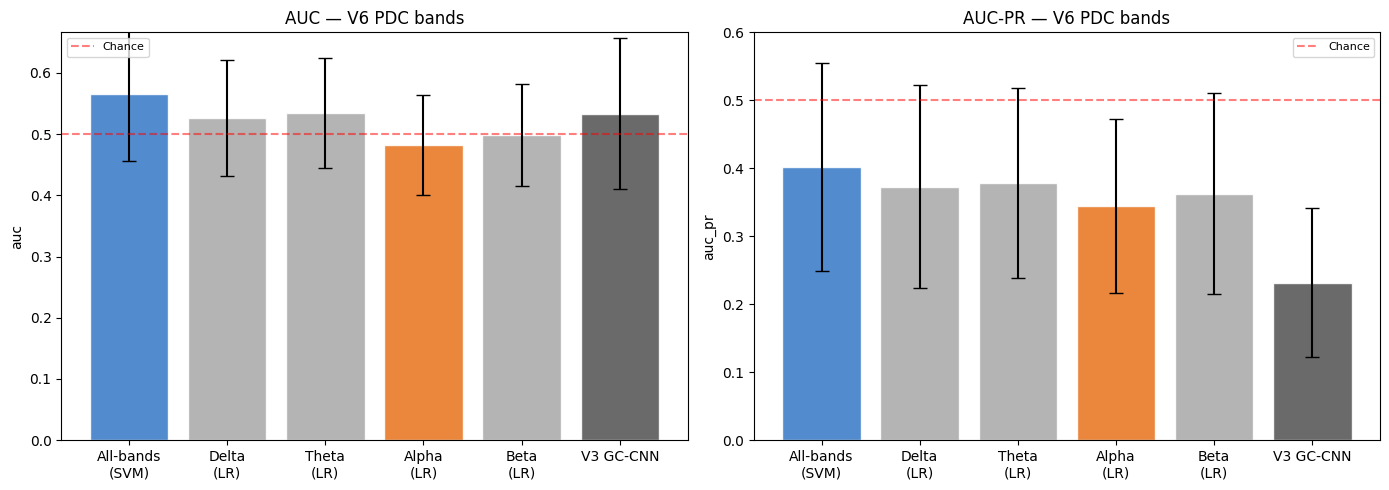

Saved results/v6_band_comparison.png


In [ ]:
# Cell 11 — Band comparison bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['auc', 'auc_pr']):
    labels, vals, errs = [], [], []

    # All-bands combined (best model)
    best_comb = max(all_results_combined.keys(),
                    key=lambda k: all_results_combined[k][metric].mean())
    df = all_results_combined[best_comb]
    labels.append(f'All-bands\n({best_comb})')
    vals.append(df[metric].mean())
    errs.append(df[metric].std())

    # Per-band (LR)
    for bname in BAND_NAMES:
        key = f'LR_{bname}'
        if key not in band_results:
            continue
        df = band_results[key]
        labels.append(f'{bname.capitalize()}\n(LR)')
        vals.append(df[metric].mean())
        errs.append(df[metric].std())

    # V3 baseline
    v3 = load_lopo_csv_clean(os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'))
    if v3 is not None:
        labels.append('V3 GC-CNN')
        vals.append(v3[metric].astype(float).mean())
        errs.append(v3[metric].astype(float).std())

    colors = ['#3a7bc8'] + ['#e87722' if b == 'alpha' else '#aaa'
                             for b in BAND_NAMES] + ['#555']
    ax.bar(labels, vals, yerr=errs, color=colors[:len(labels)],
           capsize=5, edgecolor='white', alpha=0.88)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
    ax.set_title(f'{metric.upper().replace("_","-")} — V6 PDC bands')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(0.6, max(vals) + 0.1))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_band_comparison.png'), dpi=130)
plt.show()
print('Saved results/v6_band_comparison.png')

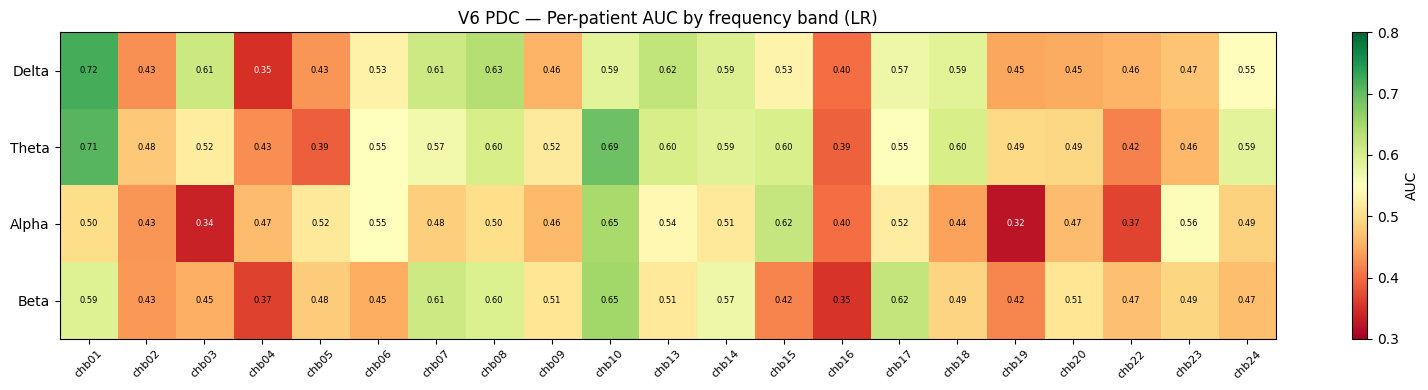

Saved results/v6_per_patient_band_heatmap.png


In [ ]:
# Cell 12 — Per-patient AUC heatmap: bands × patients

pids_sorted = sorted(patient_ids)
n_pat = len(pids_sorted)

# Build matrix: rows = bands, cols = patients
auc_matrix = np.full((len(BAND_NAMES), n_pat), np.nan)
for r, bname in enumerate(BAND_NAMES):
    key = f'LR_{bname}'
    if key not in band_results:
        continue
    df = band_results[key].set_index('patient')
    for c, pid in enumerate(pids_sorted):
        if pid in df.index:
            auc_matrix[r, c] = float(df.loc[pid, 'auc'])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(auc_matrix, aspect='auto', cmap='RdYlGn', vmin=0.3, vmax=0.8)
ax.set_xticks(range(n_pat))
ax.set_xticklabels(pids_sorted, rotation=45, fontsize=8)
ax.set_yticks(range(len(BAND_NAMES)))
ax.set_yticklabels([b.capitalize() for b in BAND_NAMES])
ax.set_title('V6 PDC — Per-patient AUC by frequency band (LR)')
plt.colorbar(im, ax=ax, label='AUC')

# Annotate cells
for r in range(len(BAND_NAMES)):
    for c in range(n_pat):
        if not np.isnan(auc_matrix[r, c]):
            ax.text(c, r, f'{auc_matrix[r, c]:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='black' if 0.35 < auc_matrix[r, c] < 0.75 else 'white')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_per_patient_band_heatmap.png'), dpi=130)
plt.show()
print('Saved results/v6_per_patient_band_heatmap.png')

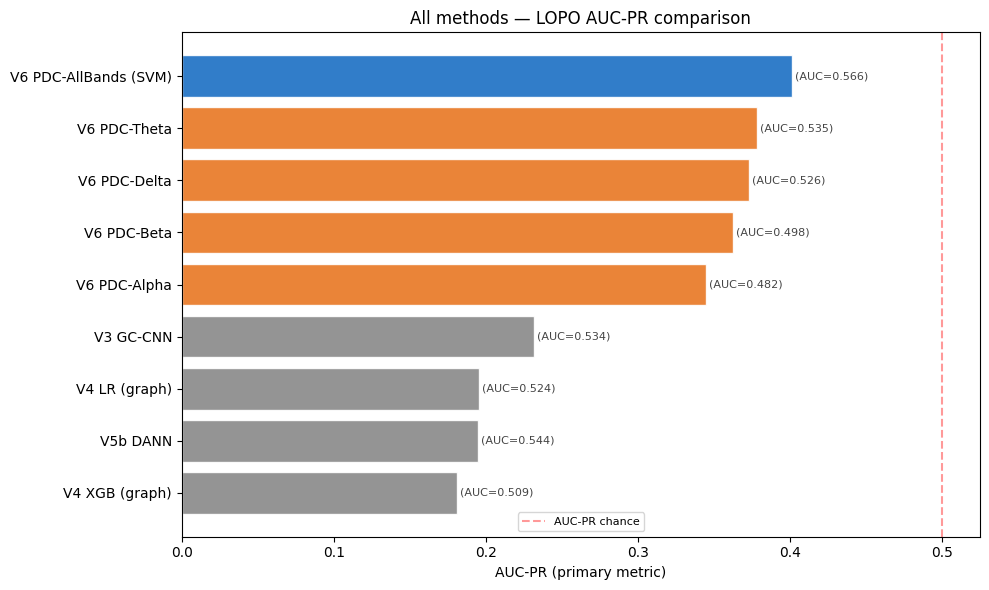

Saved results/v6_all_methods_comparison.png


In [ ]:
# Cell 13 — Overall cross-version comparison (all methods on one chart)

summary_all = []

prev_methods = {
    'V3 GC-CNN':           'lopo_v3_window.csv',
    'V4 LR (graph)':       'lopo_v4_LR.csv',
    'V4 XGB (graph)':      'lopo_v4_XGB.csv',
    'V5b DANN':            'lopo_v5b_dann.csv',
}

for label, fname in prev_methods.items():
    df = load_lopo_csv_clean(os.path.join(RESULTS_DIR, fname))
    if df is not None and 'auc_pr' in df.columns:
        summary_all.append({
            'method': label,
            'auc':    df['auc'].astype(float).mean(),
            'auc_pr': df['auc_pr'].astype(float).mean(),
            'type': 'baseline'
        })

for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key in band_results:
        df = band_results[key]
        summary_all.append({
            'method': f'V6 PDC-{bname.capitalize()}',
            'auc':    df['auc'].mean(),
            'auc_pr': df['auc_pr'].mean(),
            'type': 'v6_band'
        })

best_comb = max(all_results_combined.keys(),
                key=lambda k: all_results_combined[k]['auc_pr'].mean())
summary_all.append({
    'method': f'V6 PDC-AllBands ({best_comb})',
    'auc':    all_results_combined[best_comb]['auc'].mean(),
    'auc_pr': all_results_combined[best_comb]['auc_pr'].mean(),
    'type': 'v6_combined'
})

df_plot = pd.DataFrame(summary_all).sort_values('auc_pr', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'baseline': '#888', 'v6_band': '#e87722', 'v6_combined': '#1a6fc4'}
bars = ax.barh(df_plot['method'], df_plot['auc_pr'],
               color=[colors[t] for t in df_plot['type']],
               edgecolor='white', alpha=0.9)

# Add AUC-ROC as secondary annotation
for bar, auc in zip(bars, df_plot['auc']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'(AUC={auc:.3f})', va='center', fontsize=8, color='#444')

ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='AUC-PR chance')
ax.set_xlabel('AUC-PR (primary metric)')
ax.set_title('All methods — LOPO AUC-PR comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_all_methods_comparison.png'), dpi=130)
plt.show()
print('Saved results/v6_all_methods_comparison.png')

## 9 · Summary and thesis interpretation

In [ ]:
# Cell 14 — Final summary

print('═' * 70)
print('V6 — Frequency-Band PDC Pipeline — Results Summary')
print('═' * 70)
print(f'\nPatients : {len(patient_ids)}')
print(f'Bands    : {BAND_NAMES}  (delta/theta/alpha/beta)')
print(f'Features : {FEATS_PER_BAND}/band × 4 bands = {FEATS_PER_BAND*4} total')
print(f'\nLiterature hypothesis (Hejazi & Motie Nasrabadi 2019):')
print(f'  Alpha-band PDC > broadband GC for cross-patient preictal detection')

print('\n══ Per-band LR results: ════════════════════════════════')
best_band_auc_pr = None
best_band_name   = None
for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key in band_results:
        df = band_results[key]
        mean_pr = df['auc_pr'].mean()
        print(f'  {bname:<7}: AUC={df["auc"].mean():.4f}  AUC-PR={mean_pr:.4f}  '
              f'Sens={df["sensitivity"].mean():.4f}')
        if best_band_auc_pr is None or mean_pr > best_band_auc_pr:
            best_band_auc_pr = mean_pr
            best_band_name   = bname

print(f'\n  Best band by AUC-PR: {best_band_name}  ({best_band_auc_pr:.4f})')

best_comb = max(all_results_combined.keys(),
                key=lambda k: all_results_combined[k]['auc_pr'].mean())
df_best = all_results_combined[best_comb]
print(f'  All-bands {best_comb}: AUC={df_best["auc"].mean():.4f}  '
      f'AUC-PR={df_best["auc_pr"].mean():.4f}')

# Compare best V6 to V3 (Wilcoxon)
v3 = load_lopo_csv_clean(os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'))
if v3 is not None and 'auc_pr' in v3.columns:
    shared = sorted(set(v3.set_index('patient').index) & set(df_best.set_index('patient').index))
    if len(shared) >= 5:
        v3_pr  = v3.set_index('patient').loc[shared, 'auc_pr'].astype(float)
        v6_pr  = df_best.set_index('patient').loc[shared, 'auc_pr'].astype(float)
        try:
            _, p_val = wilcoxon(v6_pr - v3_pr, alternative='greater', zero_method='zsplit')
            print(f'\n  Wilcoxon (V6 > V3 by AUC-PR): p={p_val:.4f} '
                  f'({"significant" if p_val < 0.05 else "not significant"} at α=0.05)')
        except ValueError:
            pass

print('\n' + '═' * 70)
print('Thesis interpretation:')
print('═' * 70)
print('• If alpha-band PDC > broadband GC: confirms Hejazi & Motie Nasrabadi')
print('  (2019) frequency-specificity of preictal directed connectivity.')
print('• If all bands collapse to ~0.5: strengthens the conclusion that')
print('  scalp EEG GC — even in specific frequency bands — cannot generalise')
print('  across patients, consistent with Nolte (2004) volume conduction.')
print('• Either result directly answers RQ2 (frequency-band specificity) and')
print('  contributes to the thesis main finding of patient-specific confounding.')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
V6 — Frequency-Band PDC Pipeline — Results Summary
══════════════════════════════════════════════════════════════════════

Patients : 21
Bands    : ['delta', 'theta', 'alpha', 'beta']  (delta/theta/alpha/beta)
Features : 67/band × 4 bands = 268 total

Literature hypothesis (Hejazi & Motie Nasrabadi 2019):
  Alpha-band PDC > broadband GC for cross-patient preictal detection

══ Per-band LR results: ════════════════════════════════
  delta  : AUC=0.5261  AUC-PR=0.3730  Sens=0.6604
  theta  : AUC=0.5349  AUC-PR=0.3783  Sens=0.6182
  alpha  : AUC=0.4822  AUC-PR=0.3446  Sens=0.5685
  beta   : AUC=0.4985  AUC-PR=0.3628  Sens=0.5359

  Best band by AUC-PR: theta  (0.3783)
  All-bands SVM: AUC=0.5664  AUC-PR=0.4016

  Wilcoxon (V6 > V3 by AUC-PR): p=0.0001 (significant at α=0.05)

══════════════════════════════════════════════════════════════════════
Thesis interpretation:
═══════════════════════════════════════════════════